
# Causal Inference Workspace: DiD & Synthetic DiD

This notebook covers:
- Difference-in-Differences (DiD)
- Synthetic DiD (simplified)
- Data generation
- Estimation + plots


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

np.random.seed(42)


/Users/lindseybang/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Generate Synthetic Data

In [2]:
n_units = 50
n_periods = 20
treatment_start = 10

data = []
for u in range(n_units):
    treated = 1 if u < 10 else 0
    unit_effect = np.random.normal()
    
    for t in range(n_periods):
        time_effect = 0.5 * t
        treatment_effect = 5 if (treated and t >= treatment_start) else 0
        noise = np.random.normal()
        
        y = 10 + unit_effect + time_effect + treatment_effect + noise
        data.append([u, t, treated, y])

df = pd.DataFrame(data, columns=["unit","time","treated","outcome"])
df["post"] = (df["time"] >= treatment_start).astype(int)

df.to_csv("simulated_data.csv", index=False)
df.head()


,unit,time,treated,outcome,post
0,0,0,1,10.358450,0
1,0,1,1,11.644403,0
2,0,2,1,13.019744,0
3,0,3,1,11.762561,0
4,0,4,1,12.262577,0


## DiD Regression

In [3]:

model = smf.ols("outcome ~ treated * post + C(unit) + C(time)", data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     206.4
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:20:58   Log-Likelihood:                -1363.0
No. Observations:                1000   AIC:                             2866.
Df Residuals:                     930   BIC:                             3210.
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         9.9013      0.137     72.402

## Plot Trends

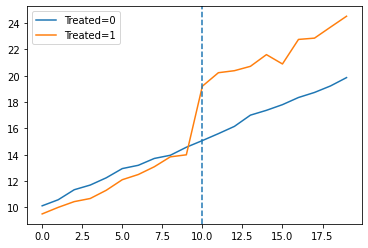

In [4]:

avg = df.groupby(["time","treated"])["outcome"].mean().reset_index()

for g in [0,1]:
    subset = avg[avg.treated == g]
    plt.plot(subset.time, subset.outcome, label=f"Treated={g}")

plt.axvline(x=10, linestyle="--")
plt.legend()
plt.show()


## Synthetic DiD (Simple Version)

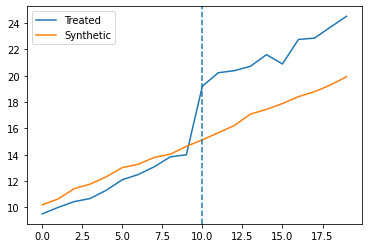

In [5]:
control = df[df.treated == 0]
treated = df[df.treated == 1]

weights = control.groupby("unit")["outcome"].mean()
weights = weights / weights.sum()

synthetic = []
for t in range(n_periods):
    val = 0
    for u, w in weights.items():
        val += w * df[(df.unit==u)&(df.time==t)]["outcome"].values[0]
    synthetic.append(val)

treated_avg = treated.groupby("time")["outcome"].mean()

plt.plot(range(n_periods), treated_avg, label="Treated")
plt.plot(range(n_periods), synthetic, label="Synthetic")
plt.axvline(x=10, linestyle="--")
plt.legend()
plt.show()
